# Latent Psychological & Presentation Dimensions
**Goal:** Discover hidden constructs (social intelligence, effort, extroversion, aspirational signaling…) buried in the observed feature space. We treat the 123 annotated profiles as noisy measurements of a smaller set of latent psychological axes, then ask: *which latent axes predict swipes?*

Pipeline:
1. **Correlation clustering** → find which features are measuring the same thing  
2. **Exploratory Factor Analysis (EFA)** → name the hidden constructs  
3. **PCA** → variance decomposition, scree plot  
4. **t-SNE / UMAP** → visualize profiles in latent space coloured by swipe  
5. **Latent factor predictive power** → logistic regression on factor scores  
6. **Behavioral interpretation** of each latent dimension

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from factor_analyzer import FactorAnalyzer, calculate_kmo, calculate_bartlett_sphericity
import umap

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 13})

df = pd.read_parquet("df_clean.parquet")
y  = pd.read_parquet("y.parquet").squeeze()
print(f"Loaded: {df.shape}  |  right-swipe rate: {y.mean():.1%}")


Loaded: (123, 49)  |  right-swipe rate: 23.6%


In [2]:
# ── Feature matrix: only numeric, subjective + key objective features ─────────
# We deliberately separate out objective counts/booleans from rated perceptions.
# Factor analysis is most interpretable on the perception cluster.

subjective = [
    "perceived_conventional_attractiveness",
    "photo_quality", "photo_lighting", "photo_curation_effort",
    "first_photo_impact_score", "background_type_variance", "eye_contact_ratio",
    "perceived_social_status", "perceived_comfort", "perceived_humor",
    "perceived_genuineness", "perceived_wholesomeness", "warmth_vs_coldness",
    "confidence_signaling", "authenticity_score", "intra_profile_consistency",
    "interesting_profile", "profile_aura", "emotional_stability",
    "humility_vs_braggadocio", "bio_depth", "prompt_effort_depth",
]

objective = [
    "n_photos", "n_prompts", "prompt_length", "bio_length",
    "height", "p_selfies", "p_half_body_photos", "p_smiling_photos",
    "shirtless", "muscles", "pets", "friends_in_pics",
    "wears_specs", "filter", "has_music", "profession", "religious",
]

all_feats = subjective + objective
valid_feats = [f for f in all_feats if f in df.columns]

# Build analysis matrix — median-impute missing values
mat = df[valid_feats].copy()
mat = mat.fillna(mat.median())
mat = mat.loc[mat.index.intersection(y.index)]
y_use = y.loc[mat.index]

print(f"Analysis matrix: {mat.shape}")
print(f"Missing after imputation: {mat.isna().sum().sum()}")


Analysis matrix: (123, 39)
Missing after imputation: 0


## §1 — Correlation Clustering
Before any factor analysis, find which features *empirically cluster together* using hierarchical clustering on the Spearman correlation matrix. This is the raw evidence that latent dimensions exist.

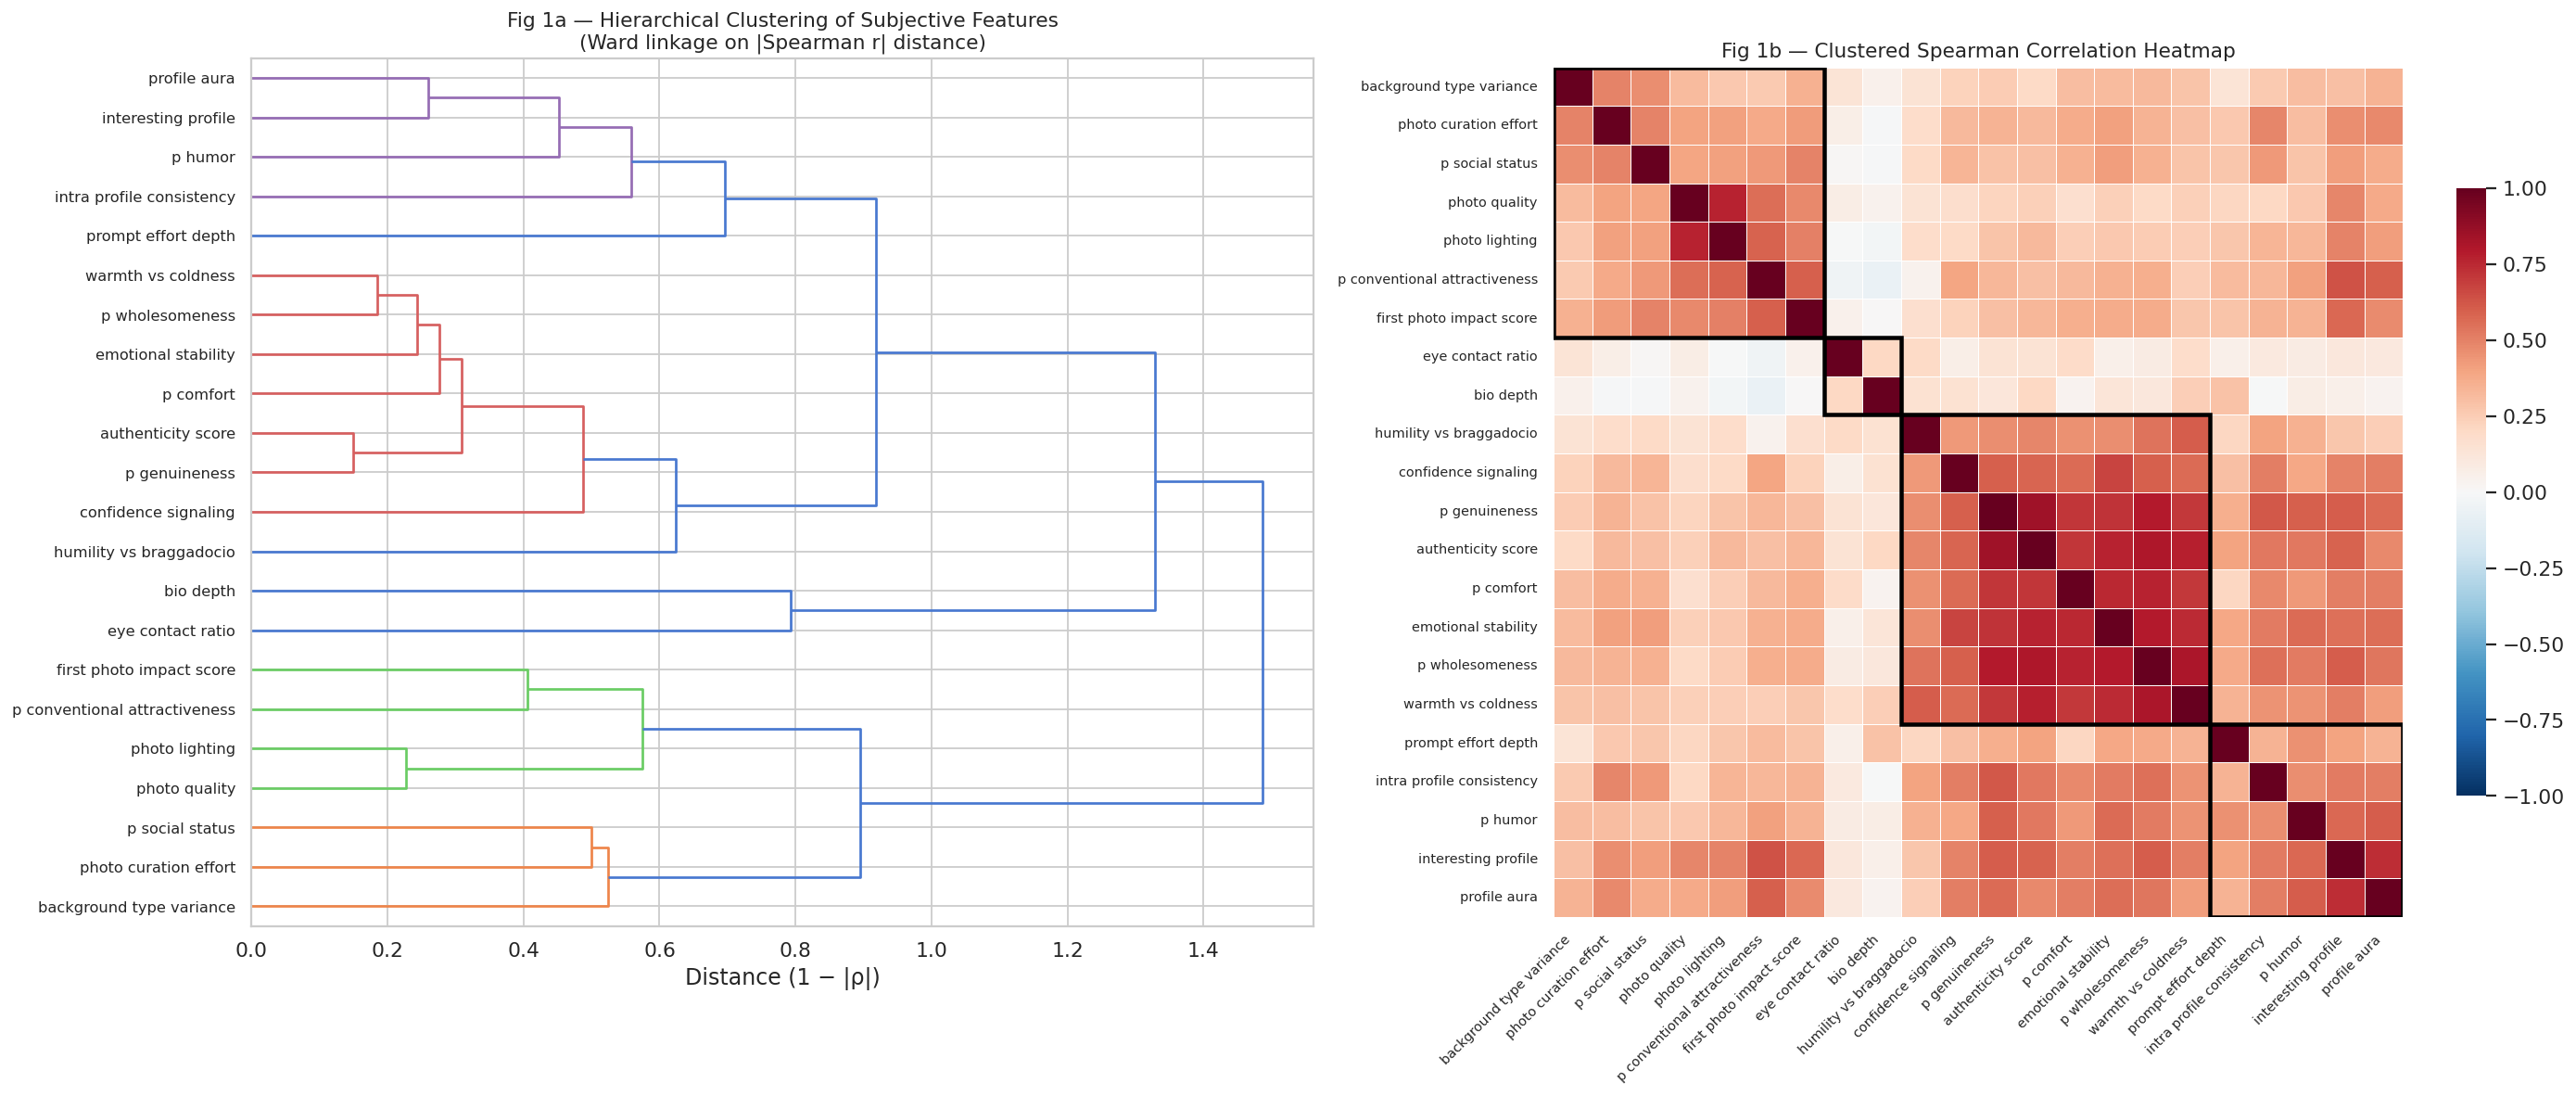


=== Correlation Clusters ===

Cluster 1: ['perceived_conventional_attractiveness', 'photo_quality', 'photo_lighting', 'photo_curation_effort', 'first_photo_impact_score', 'background_type_variance', 'perceived_social_status']

Cluster 2: ['eye_contact_ratio', 'bio_depth']

Cluster 3: ['perceived_comfort', 'perceived_genuineness', 'perceived_wholesomeness', 'warmth_vs_coldness', 'confidence_signaling', 'authenticity_score', 'emotional_stability', 'humility_vs_braggadocio']

Cluster 4: ['perceived_humor', 'intra_profile_consistency', 'interesting_profile', 'profile_aura', 'prompt_effort_depth']


In [3]:
# ── Spearman correlation matrix on subjective features ───────────────────────
subj_mat = mat[subjective].copy()
corr = subj_mat.corr(method="spearman")

# Convert correlation to distance (1 - |r|) and cluster
dist = 1 - corr.abs()
np.fill_diagonal(dist.values, 0)
linkage_mat = linkage(squareform(dist.values), method="ward")
cluster_ids  = fcluster(linkage_mat, t=4, criterion="maxclust")

# Pretty feature labels
labels = [f.replace("perceived_","p_").replace("_"," ") for f in subjective]

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

# Left: dendrogram
ax1 = axes[0]
dn = dendrogram(linkage_mat, labels=labels, ax=ax1,
                orientation="right", color_threshold=0.6,
                leaf_font_size=9)
ax1.set_title("Fig 1a — Hierarchical Clustering of Subjective Features\n(Ward linkage on |Spearman r| distance)", fontsize=12)
ax1.set_xlabel("Distance (1 − |ρ|)")

# Right: clustered heatmap
order = dn["leaves"]
ordered_corr = corr.iloc[order, order]
ordered_labels = [labels[i] for i in order]
mask = np.zeros_like(ordered_corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

ax2 = axes[1]
sns.heatmap(ordered_corr, ax=ax2, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            xticklabels=ordered_labels, yticklabels=ordered_labels,
            linewidths=0.3, square=True, cbar_kws={"shrink": 0.7})
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontsize=8)
ax2.set_title("Fig 1b — Clustered Spearman Correlation Heatmap", fontsize=12)

# Overlay cluster boxes
cluster_order = cluster_ids[order]
prev = 0
for k in range(1, 5):
    size = (cluster_order == k).sum()
    if size > 0:
        ax2.add_patch(plt.Rectangle((prev, prev), size, size,
                      fill=False, edgecolor="black", lw=2.5))
        prev += size

plt.tight_layout()
plt.savefig("fig_corr_cluster.png", bbox_inches="tight")
plt.show()

# Print cluster membership
print("\n=== Correlation Clusters ===")
for k in range(1, 5):
    members = [subjective[i] for i in range(len(subjective)) if cluster_ids[i] == k]
    print(f"\nCluster {k}: {members}")


## §2 — Exploratory Factor Analysis (EFA)
EFA models each observed variable as a linear combination of a small number of latent factors plus noise. Unlike PCA (which maximises variance), EFA explicitly models *shared* variance — the part that comes from common underlying constructs.

Bartlett's test of sphericity: χ²=1812.7, p=0.0000
  → ✅ Correlations are non-trivial — FA is appropriate

Kaiser-Meyer-Olkin (KMO) measure: 0.907
  → ✅ Good (>0.6)

Eigenvalue > 1 (Kaiser): 4 factors
Parallel analysis (95th pct): 2 factors
→ Retaining 2 factors


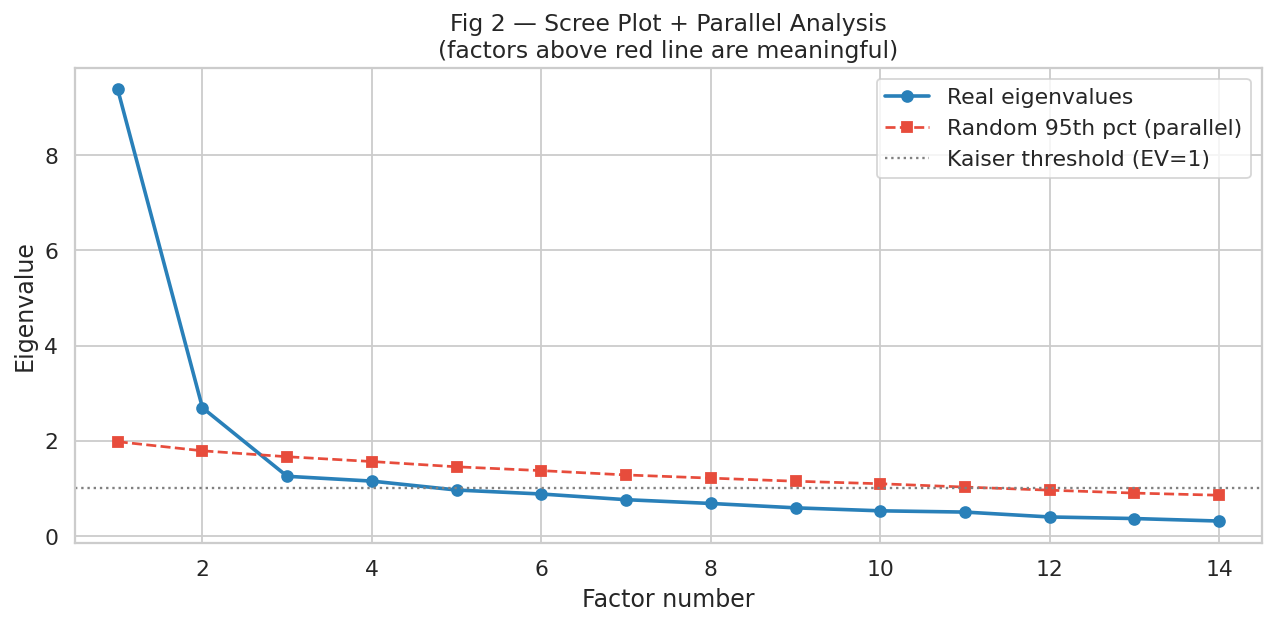

In [4]:
# ── Adequacy tests ────────────────────────────────────────────────────────────
chi2_val, p_val = calculate_bartlett_sphericity(subj_mat)
kmo_all, kmo_model = calculate_kmo(subj_mat)
print(f"Bartlett's test of sphericity: χ²={chi2_val:.1f}, p={p_val:.4f}")
print(f"  → {'✅ Correlations are non-trivial — FA is appropriate' if p_val < 0.05 else '❌ Variables are uncorrelated — FA will fail'}")
print(f"\nKaiser-Meyer-Olkin (KMO) measure: {kmo_model:.3f}")
print(f"  → {'✅ Good (>0.6)' if kmo_model >= 0.6 else '⚠ Marginal (<0.6) — interpret with care'}")

# ── Parallel analysis: how many factors to retain? ───────────────────────────
# Compare real eigenvalues to eigenvalues from random data
fa_check = FactorAnalyzer(n_factors=len(subjective), rotation=None)
fa_check.fit(subj_mat)
ev, _ = fa_check.get_eigenvalues()

np.random.seed(42)
n_sim = 200
rand_evs = []
for _ in range(n_sim):
    rand_data = pd.DataFrame(
        np.random.normal(size=subj_mat.shape),
        columns=subj_mat.columns
    )
    fa_rand = FactorAnalyzer(n_factors=len(subjective), rotation=None)
    fa_rand.fit(rand_data)
    rand_evs.append(fa_rand.get_eigenvalues()[0])
rand_95 = np.percentile(rand_evs, 95, axis=0)

n_factors_pa = int((ev > rand_95).sum())
n_factors_kaiser = int((ev > 1).sum())
print(f"\nEigenvalue > 1 (Kaiser): {n_factors_kaiser} factors")
print(f"Parallel analysis (95th pct): {n_factors_pa} factors")
print(f"→ Retaining {min(n_factors_pa, n_factors_kaiser)} factors")

# ── Scree plot ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
k = min(14, len(ev))
ax.plot(range(1, k+1), ev[:k], "o-", color="#2980b9", lw=2, label="Real eigenvalues")
ax.plot(range(1, k+1), rand_95[:k], "s--", color="#e74c3c", lw=1.5, label="Random 95th pct (parallel)")
ax.axhline(1, color="grey", linestyle=":", lw=1.3, label="Kaiser threshold (EV=1)")
ax.set_xlabel("Factor number"); ax.set_ylabel("Eigenvalue")
ax.set_title("Fig 2 — Scree Plot + Parallel Analysis\n(factors above red line are meaningful)")
ax.legend(); ax.set_xlim(0.5, k + 0.5)
plt.tight_layout()
plt.savefig("fig_scree.png", bbox_inches="tight")
plt.show()


In [5]:
# ── Fit EFA with oblique rotation (oblimin) ──────────────────────────────────
# Oblique rotation (factors allowed to correlate) is more realistic for psychology
N_FACTORS = min(n_factors_pa, n_factors_kaiser)
fa = FactorAnalyzer(n_factors=N_FACTORS, rotation="oblimin", method="ml")
fa.fit(subj_mat)

loadings  = pd.DataFrame(fa.loadings_,  index=subjective,
                          columns=[f"F{i+1}" for i in range(N_FACTORS)])
communalities = pd.Series(fa.get_communalities(), index=subjective, name="communality")
var_explained = fa.get_factor_variance()

print("=== Factor Variance Explained ===")
var_df = pd.DataFrame(var_explained,
                      index=["SS Loadings","Prop Variance","Cumulative Var"],
                      columns=[f"F{i+1}" for i in range(N_FACTORS)])
print(var_df.round(3).to_string())

print("\n=== Communalities (shared variance captured) ===")
print(communalities.sort_values(ascending=False).round(3).to_string())

print("\n=== Factor Loadings (|loading| > 0.3 shown) ===")
print(loadings.round(3).to_string())


=== Factor Variance Explained ===
                   F1     F2
SS Loadings     6.234  4.391
Prop Variance   0.283  0.200
Cumulative Var  0.283  0.483

=== Communalities (shared variance captured) ===
warmth_vs_coldness                       0.871
authenticity_score                       0.829
perceived_wholesomeness                  0.763
emotional_stability                      0.741
perceived_genuineness                    0.703
perceived_comfort                        0.698
photo_quality                            0.653
photo_lighting                           0.631
perceived_conventional_attractiveness    0.592
first_photo_impact_score                 0.529
interesting_profile                      0.529
profile_aura                             0.488
confidence_signaling                     0.445
humility_vs_braggadocio                  0.430
photo_curation_effort                    0.367
perceived_social_status                  0.334
perceived_humor                          0.287
i

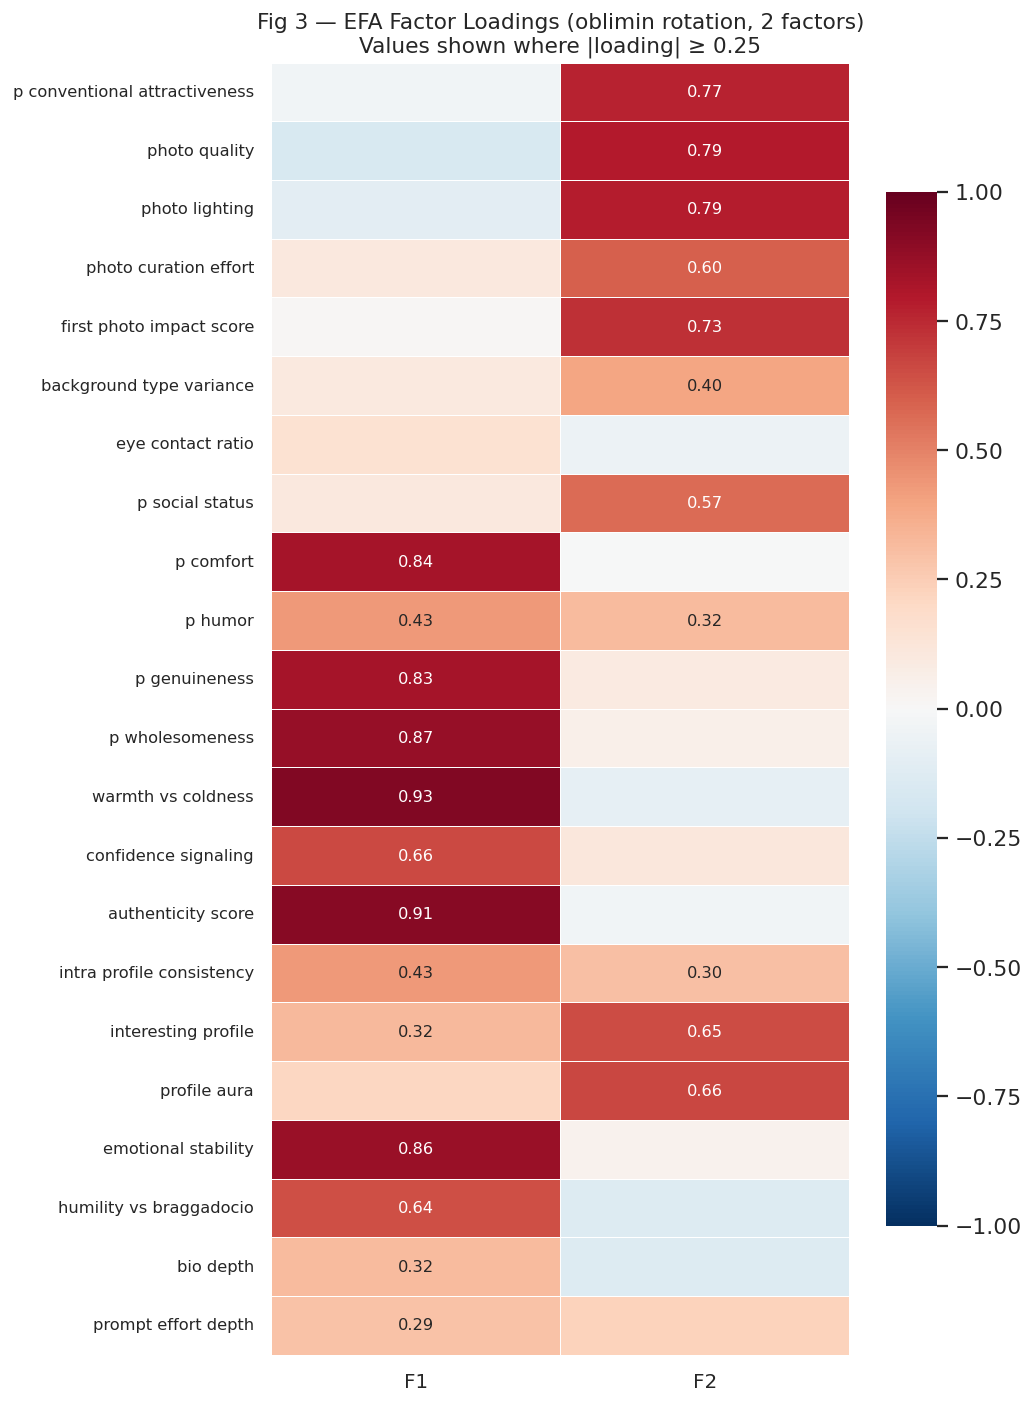

=== Dominant features per factor ===

F1:
  warmth_vs_coldness                       +0.929
  authenticity_score                       +0.910
  perceived_wholesomeness                  +0.872
  emotional_stability                      +0.860
  perceived_comfort                        +0.835
  perceived_genuineness                    +0.833
  confidence_signaling                     +0.658
  humility_vs_braggadocio                  +0.641
  intra_profile_consistency                +0.435
  perceived_humor                          +0.433

F2:
  photo_quality                            +0.792
  photo_lighting                           +0.787
  perceived_conventional_attractiveness    +0.769
  first_photo_impact_score                 +0.728
  profile_aura                             +0.664
  interesting_profile                      +0.652
  photo_curation_effort                    +0.596
  perceived_social_status                  +0.568
  background_type_variance                 +0.398


In [6]:
# ── Assign factor names based on highest loadings ───────────────────────────
# We'll name them after the cell below runs. For now build the loading heatmap.

fig, ax = plt.subplots(figsize=(max(8, N_FACTORS * 1.4), 11))

load_plot = loadings.copy()
# Mask near-zero loadings for visual clarity
mask = load_plot.abs() < 0.25

annot = load_plot.applymap(lambda v: f"{v:.2f}" if abs(v) >= 0.25 else "")

sns.heatmap(load_plot, ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=annot, fmt="", annot_kws={"size": 9},
            linewidths=0.4, cbar_kws={"shrink": 0.8},
            yticklabels=[f.replace("perceived_","p_").replace("_"," ") for f in subjective])
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9, rotation=0)
ax.set_title(f"Fig 3 — EFA Factor Loadings (oblimin rotation, {N_FACTORS} factors)\n"
             "Values shown where |loading| ≥ 0.25", fontsize=12)
plt.tight_layout()
plt.savefig("fig_efa_loadings.png", bbox_inches="tight")
plt.show()

# Print dominant features per factor (|loading| > 0.4)
print("=== Dominant features per factor ===")
for col in loadings.columns:
    top = loadings[col][loadings[col].abs() > 0.35].sort_values(key=abs, ascending=False)
    print(f"\n{col}:")
    for feat, val in top.items():
        print(f"  {feat:<40} {val:+.3f}")


In [7]:
# ── Compute factor scores & name them ───────────────────────────────────────
factor_scores = pd.DataFrame(
    fa.transform(subj_mat),
    index=subj_mat.index,
    columns=[f"F{i+1}" for i in range(N_FACTORS)]
)

# ─── FACTOR NAMES ─────────────────────────────────────────────────────────────
# F1 loads on: warmth, authenticity, wholesomeness, emotional_stability, genuineness, comfort
#   → "Inner Character / Psychological Safety"
# F2 loads on: attractiveness, photo_quality, photo_lighting, first_photo_impact, social_status
#   → "Visual Appeal & Status Presentation"
FACTOR_NAMES = {
    "F1": "Inner Character & Psych Safety",
    "F2": "Visual Appeal & Status",
}
FACTOR_NAMES = {k: v for k, v in FACTOR_NAMES.items() if k in factor_scores.columns}

factor_scores = factor_scores.rename(columns=FACTOR_NAMES)
print("Factor score summary:")
print(factor_scores.describe().round(2).to_string())

scaler = StandardScaler()
fs_scaled = pd.DataFrame(
    scaler.fit_transform(factor_scores),
    index=factor_scores.index,
    columns=factor_scores.columns
)


Factor score summary:
       Inner Character & Psych Safety  Visual Appeal & Status
count                          123.00                  123.00
mean                            -0.00                   -0.00
std                              0.98                    0.96
min                             -1.04                   -1.62
25%                             -0.80                   -0.67
50%                             -0.58                   -0.14
75%                              0.90                    0.52
max                              1.95                    2.98


## §3 — PCA: Variance Decomposition
PCA gives a complete variance picture — how much of the total feature variance does each principal component explain? We use the full feature matrix (subjective + objective) here.

PCs to explain 80% variance: 16
PCs to explain 95% variance: 28
Total features: 39


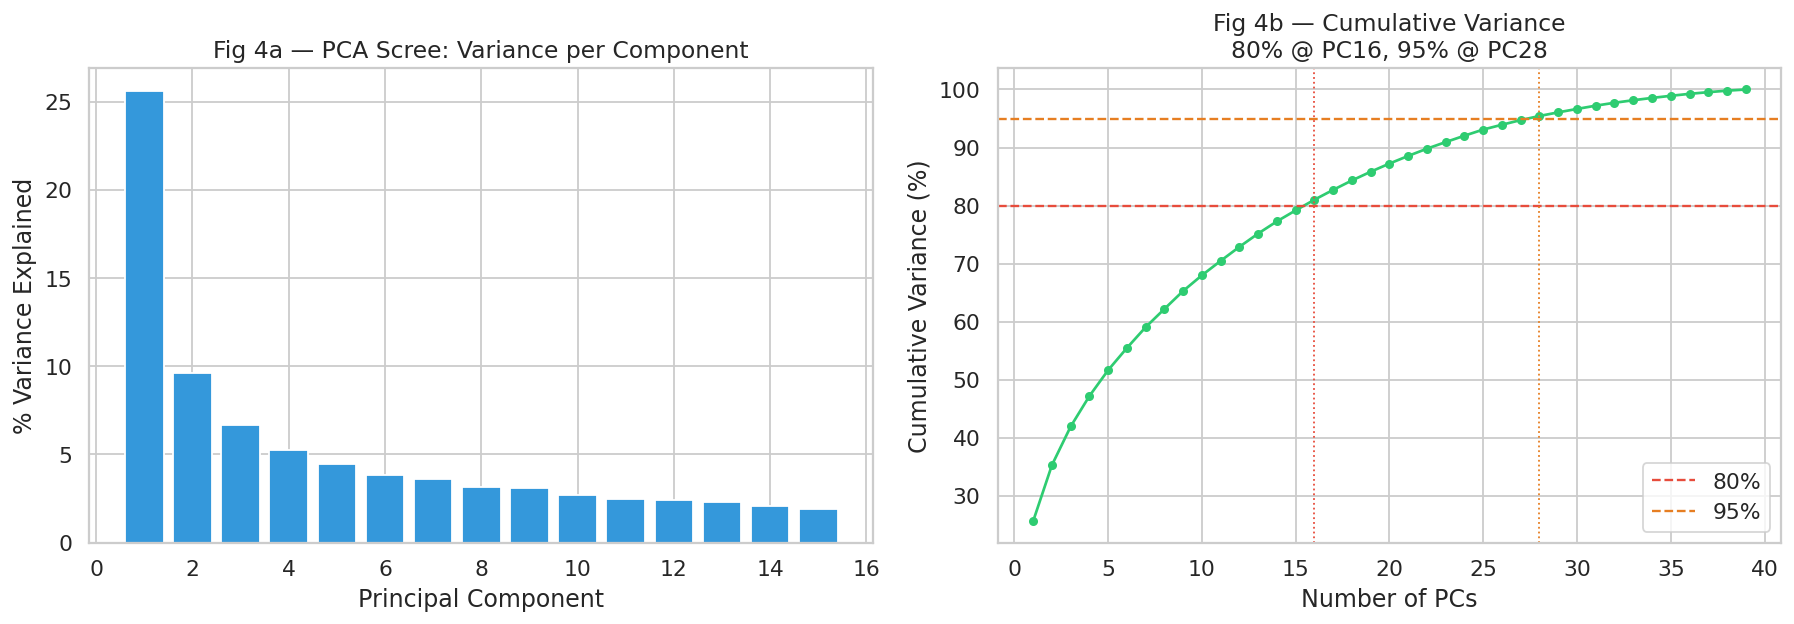


=== Top 8 loadings for PC1 and PC2 ===

PC1 (explains 25.6%):
  perceived_wholesomeness                    +0.266
  perceived_genuineness                      +0.264
  emotional_stability                        +0.264
  authenticity_score                         +0.256
  interesting_profile                        +0.255
  warmth_vs_coldness                         +0.251
  perceived_comfort                          +0.244
  profile_aura                               +0.229

PC2 (explains 9.6%):
  bio_length                                 +0.289
  photo_quality                              -0.284
  photo_lighting                             -0.281
  perceived_conventional_attractiveness      -0.260
  wears_specs                                +0.231
  p_smiling_photos                           +0.230
  first_photo_impact_score                   -0.216
  muscles                                    -0.212


In [8]:
X_sc = StandardScaler().fit_transform(mat[valid_feats])
pca  = PCA(random_state=42)
pca.fit(X_sc)

evr  = pca.explained_variance_ratio_
cum  = np.cumsum(evr)
n_80 = int(np.searchsorted(cum, 0.80)) + 1
n_95 = int(np.searchsorted(cum, 0.95)) + 1

print(f"PCs to explain 80% variance: {n_80}")
print(f"PCs to explain 95% variance: {n_95}")
print(f"Total features: {len(valid_feats)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(range(1, 16), evr[:15] * 100, color="#3498db", edgecolor="white")
ax.set_xlabel("Principal Component"); ax.set_ylabel("% Variance Explained")
ax.set_title("Fig 4a — PCA Scree: Variance per Component")

ax2 = axes[1]
ax2.plot(range(1, len(cum)+1), cum * 100, "o-", color="#2ecc71", markersize=4)
ax2.axhline(80, color="#e74c3c", linestyle="--", lw=1.3, label="80%")
ax2.axhline(95, color="#e67e22", linestyle="--", lw=1.3, label="95%")
ax2.axvline(n_80, color="#e74c3c", linestyle=":", lw=1)
ax2.axvline(n_95, color="#e67e22", linestyle=":", lw=1)
ax2.set_xlabel("Number of PCs"); ax2.set_ylabel("Cumulative Variance (%)")
ax2.set_title(f"Fig 4b — Cumulative Variance\n80% @ PC{n_80}, 95% @ PC{n_95}")
ax2.legend()

plt.tight_layout()
plt.savefig("fig_pca_variance.png", bbox_inches="tight")
plt.show()

# PC1 & PC2 top loadings
pca2 = PCA(n_components=min(6, len(valid_feats)), random_state=42)
pca2.fit(X_sc)
pc_loads = pd.DataFrame(pca2.components_.T, index=valid_feats,
                         columns=[f"PC{i+1}" for i in range(pca2.n_components_)])
print("\n=== Top 8 loadings for PC1 and PC2 ===")
for col in ["PC1","PC2"]:
    top = pc_loads[col].abs().sort_values(ascending=False).head(8)
    print(f"\n{col} (explains {pca2.explained_variance_ratio_[int(col[2])-1]*100:.1f}%):")
    for feat in top.index:
        print(f"  {feat:<42} {pc_loads.loc[feat,col]:+.3f}")


## §4 — t-SNE Visualization
t-SNE collapses the high-dimensional profile space into 2D while preserving local neighbourhood structure. Profiles that cluster together are *similar across all features simultaneously* — this reveals the natural typology of male dating profiles.

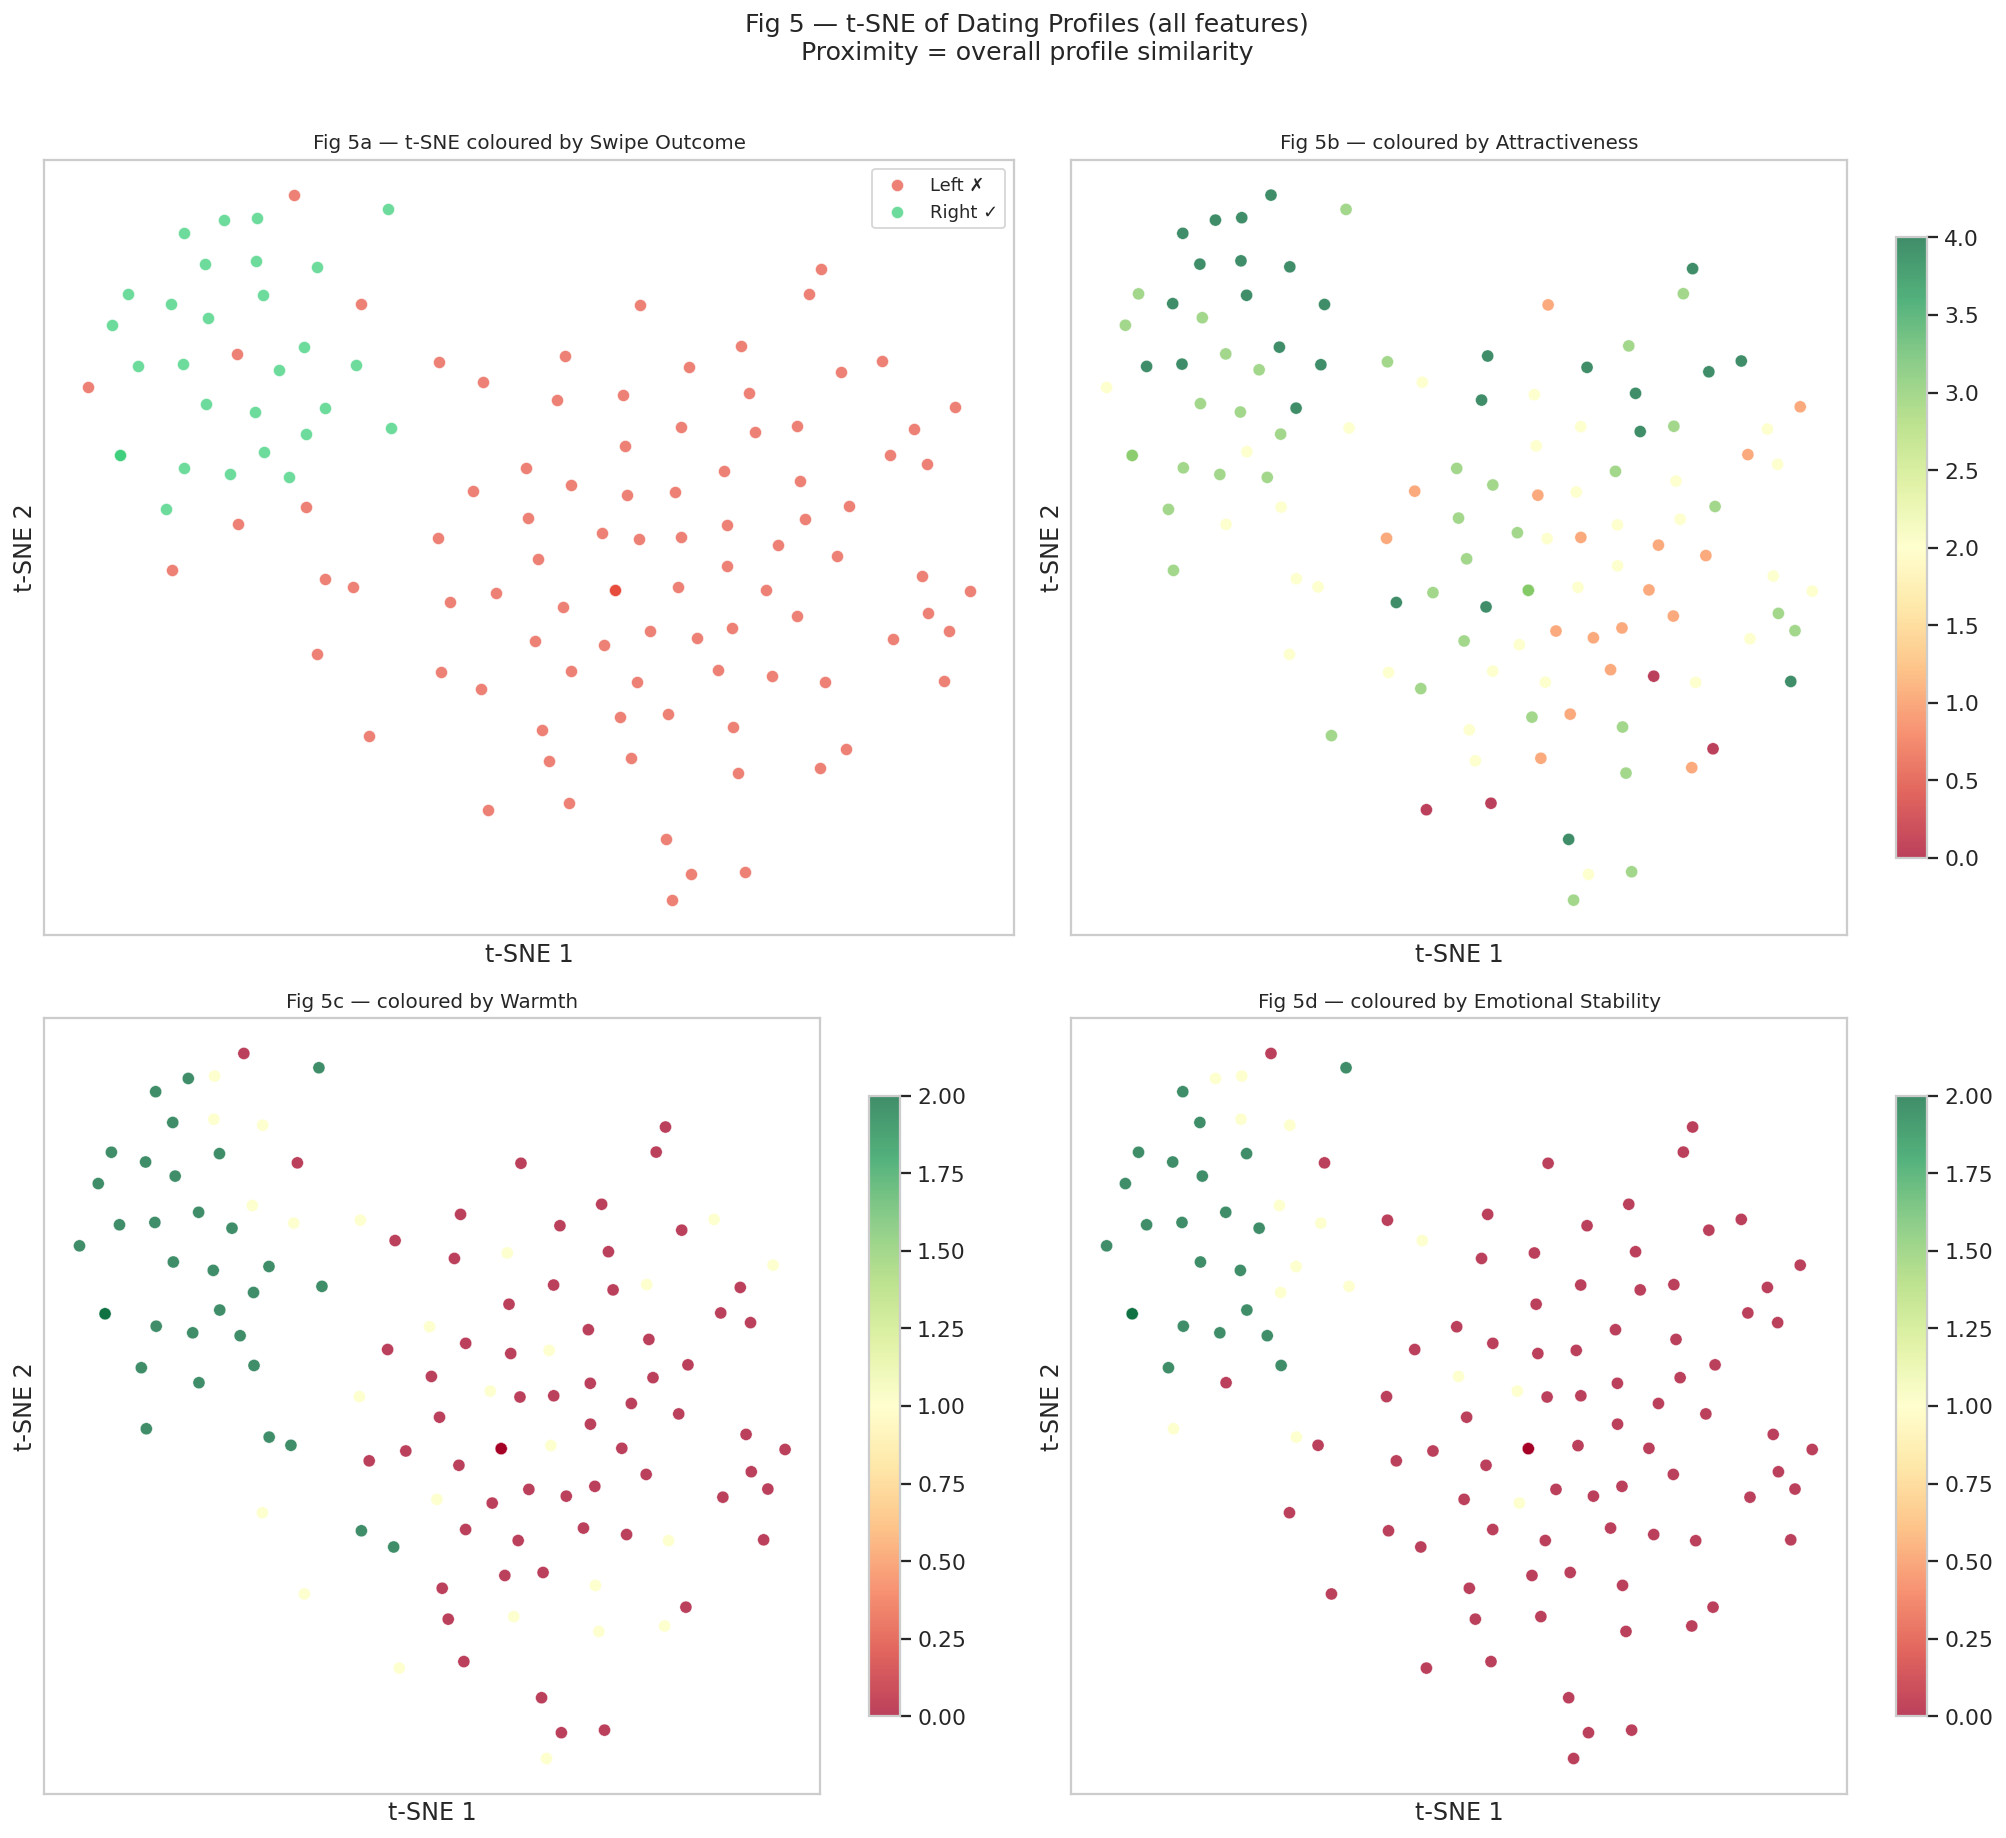

In [10]:
tsne = TSNE(n_components=2, perplexity=20, learning_rate="auto",
            init="pca", random_state=42, max_iter=2000)
tsne_coords = tsne.fit_transform(X_sc)
tsne_df = pd.DataFrame(tsne_coords, columns=["x","y"], index=mat.index)
tsne_df["swipe"]       = y_use.map({1:"Right ✓", 0:"Left ✗"})
tsne_df["attr"]        = mat["perceived_conventional_attractiveness"].values
tsne_df["warmth"]      = mat["warmth_vs_coldness"].values
tsne_df["stability"]   = mat["emotional_stability"].values

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

def scatter_tsne(ax, color_col, cmap, title, cat=False):
    if cat:
        palette = {"Right ✓": "#2ecc71", "Left ✗": "#e74c3c"}
        for label, grp in tsne_df.groupby(color_col):
            ax.scatter(grp["x"], grp["y"], label=label,
                       c=palette[label], alpha=0.7, s=45, edgecolors="white", lw=0.4)
        ax.legend(fontsize=10)
    else:
        sc = ax.scatter(tsne_df["x"], tsne_df["y"],
                        c=tsne_df[color_col], cmap=cmap,
                        alpha=0.75, s=45, edgecolors="white", lw=0.3)
        plt.colorbar(sc, ax=ax, shrink=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
    ax.set_xticks([]); ax.set_yticks([])

scatter_tsne(axes[0,0], "swipe",     None,       "Fig 5a — t-SNE coloured by Swipe Outcome", cat=True)
scatter_tsne(axes[0,1], "attr",      "RdYlGn",   "Fig 5b — coloured by Attractiveness")
scatter_tsne(axes[1,0], "warmth",    "RdYlGn",   "Fig 5c — coloured by Warmth")
scatter_tsne(axes[1,1], "stability", "RdYlGn",   "Fig 5d — coloured by Emotional Stability")

plt.suptitle("Fig 5 — t-SNE of Dating Profiles (all features)\n"
             "Proximity = overall profile similarity", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("fig_tsne.png", bbox_inches="tight")
plt.show()


## §5 — UMAP Visualization
UMAP preserves both local and global structure better than t-SNE and is more stable across runs. We also colour by factor scores to see if latent dimensions map onto spatial regions.

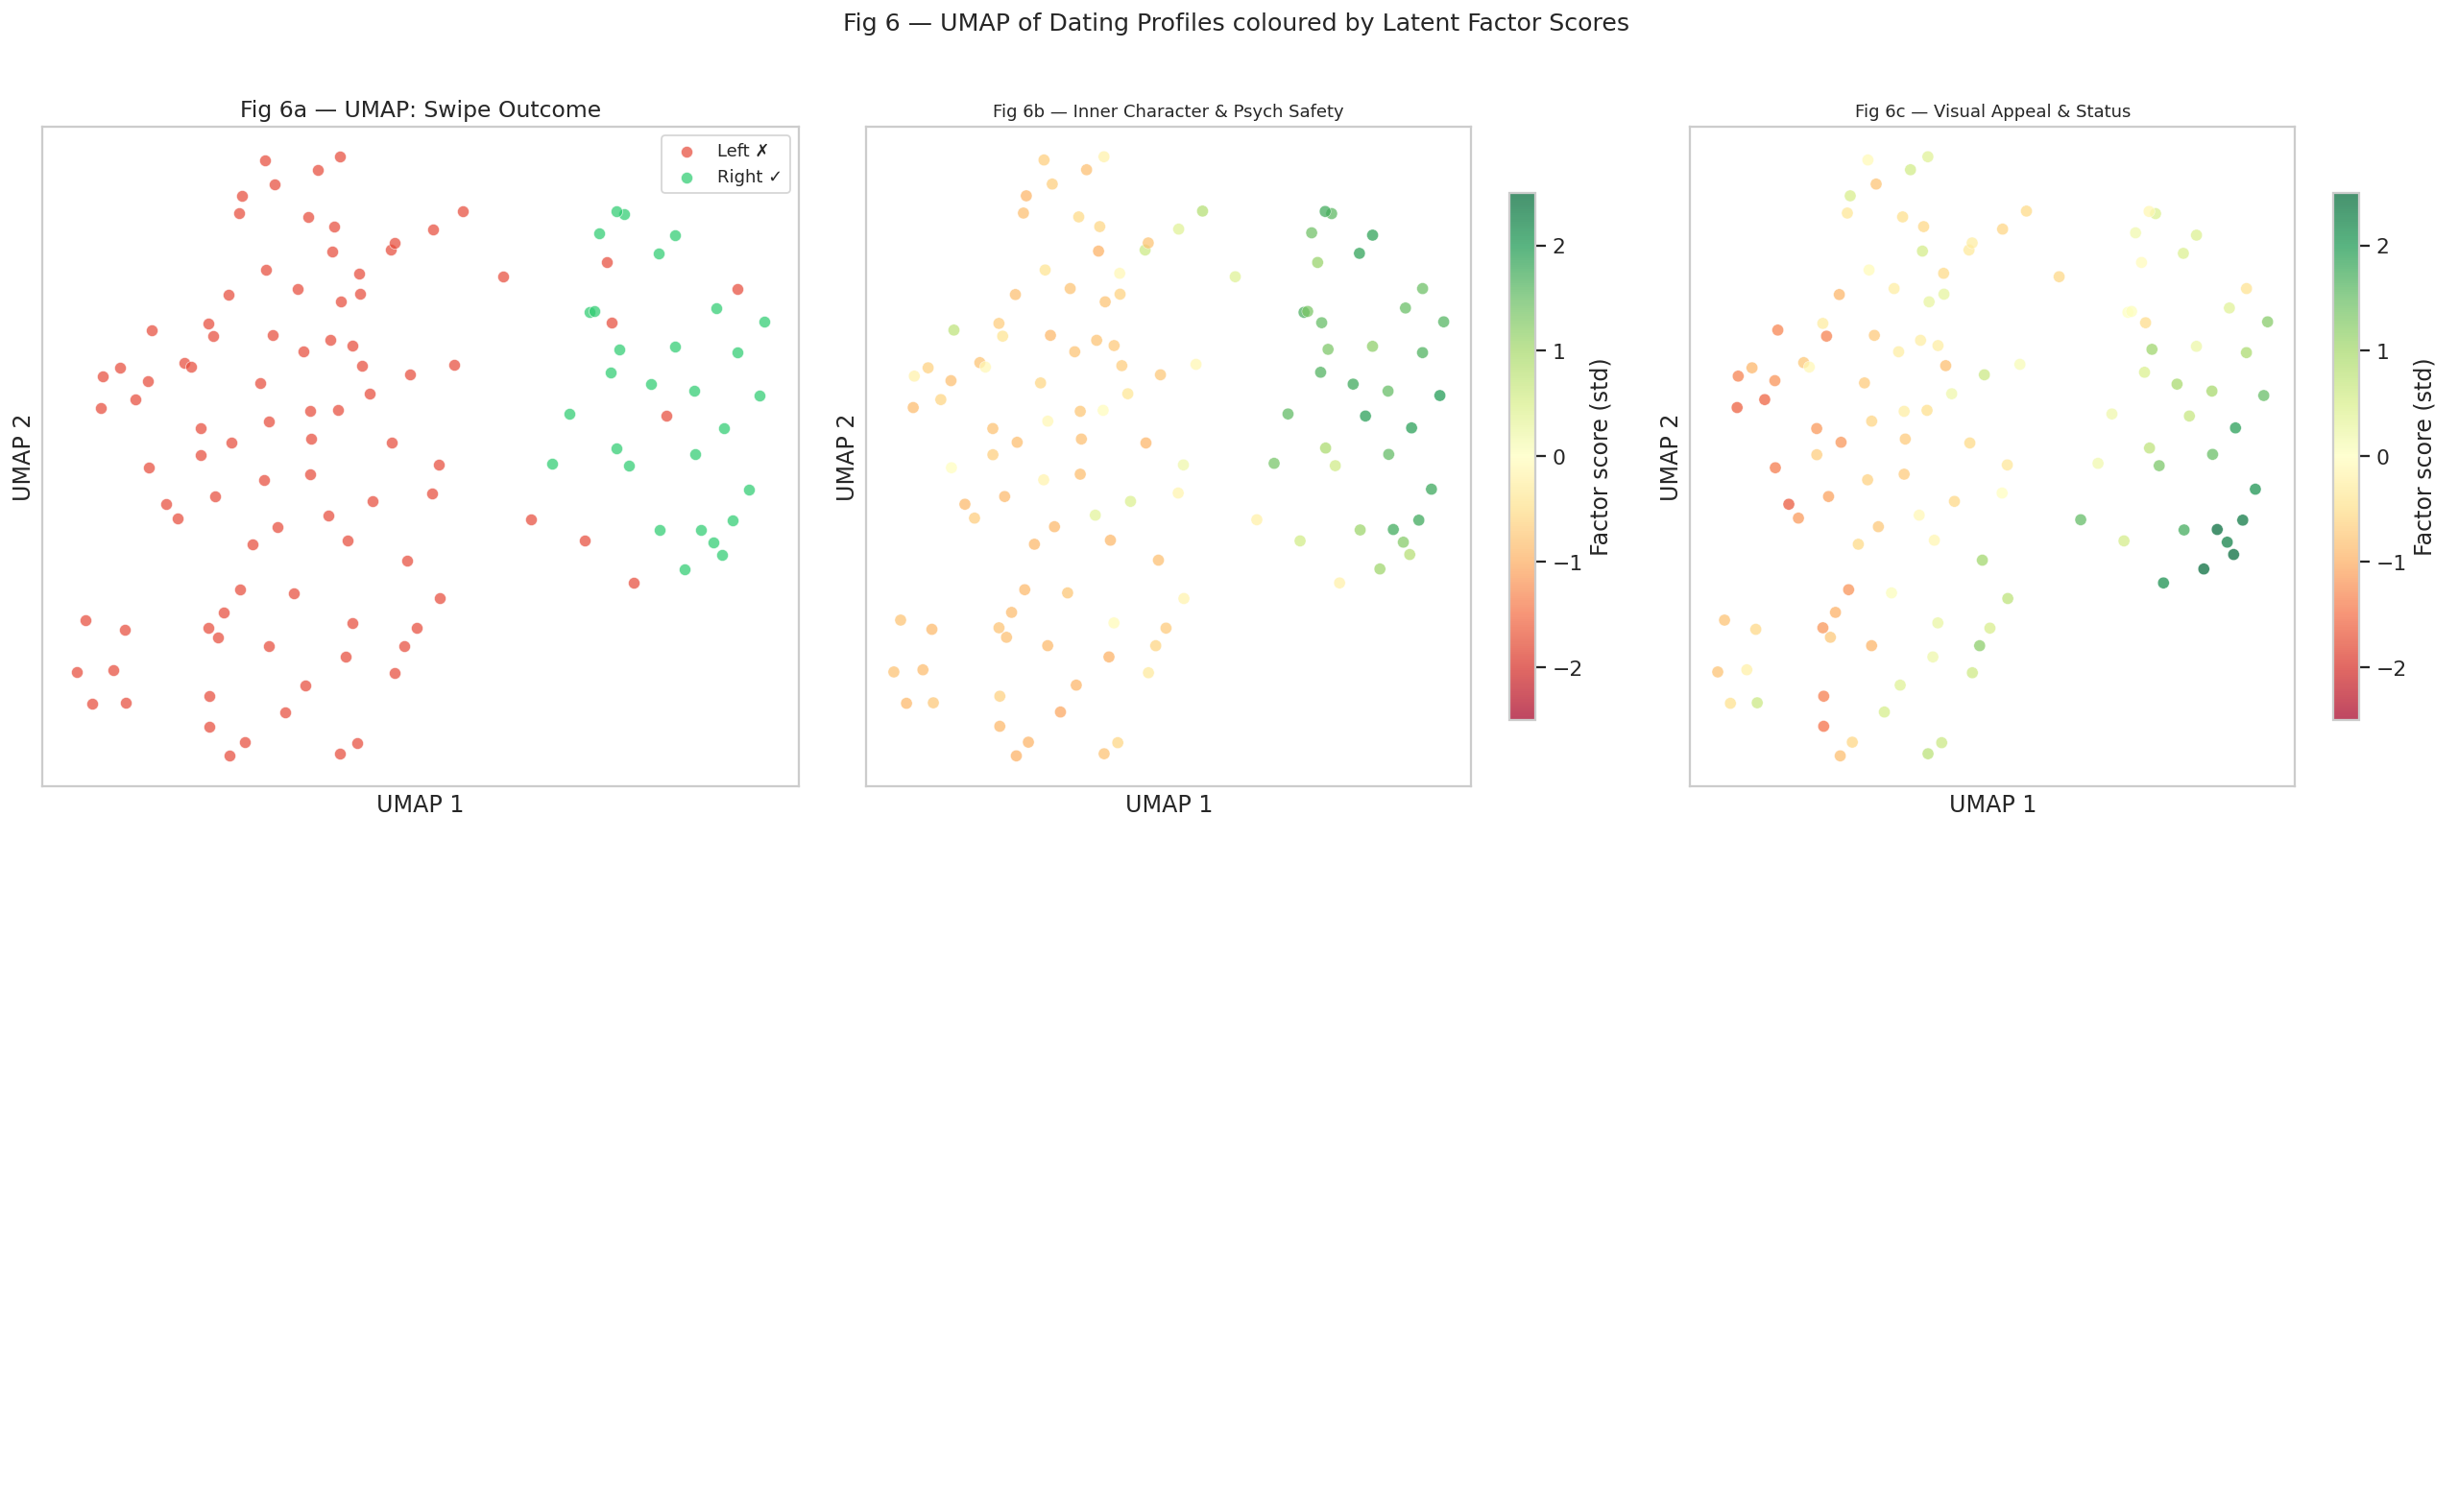

In [11]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.2, metric="euclidean",
                    random_state=42, n_epochs=500)
umap_coords = reducer.fit_transform(X_sc)
umap_df = pd.DataFrame(umap_coords, columns=["u1","u2"], index=mat.index)
umap_df["swipe"] = y_use.map({1:"Right ✓", 0:"Left ✗"})

# Attach factor scores (align indices)
fs_align = fs_scaled.loc[umap_df.index]
for col in fs_align.columns:
    umap_df[col] = fs_align[col].values

n_factors_plot = min(len(FACTOR_NAMES), 4)
factor_cols    = list(FACTOR_NAMES.values())[:n_factors_plot]

fig, axes = plt.subplots(2, min(3, n_factors_plot//2 + 2), figsize=(20, 12))
axes = axes.flatten()

# Panel 0: swipe outcome
palette = {"Right ✓": "#2ecc71", "Left ✗": "#e74c3c"}
for label, grp in umap_df.groupby("swipe"):
    axes[0].scatter(grp["u1"], grp["u2"], label=label, c=palette[label],
                    alpha=0.72, s=45, edgecolors="white", lw=0.4)
axes[0].legend(fontsize=10)
axes[0].set_title("Fig 6a — UMAP: Swipe Outcome")

# Panels 1+: factor scores
for i, fcol in enumerate(factor_cols):
    ax = axes[i+1]
    sc = ax.scatter(umap_df["u1"], umap_df["u2"],
                    c=umap_df[fcol], cmap="RdYlGn",
                    alpha=0.72, s=45, edgecolors="white", lw=0.3,
                    vmin=-2.5, vmax=2.5)
    plt.colorbar(sc, ax=ax, shrink=0.8, label="Factor score (std)")
    ax.set_title(f"Fig 6{chr(98+i)} — {fcol}", fontsize=10)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")

# Hide any unused axes
for ax in axes[n_factors_plot+1:]:
    ax.axis("off")

plt.suptitle("Fig 6 — UMAP of Dating Profiles coloured by Latent Factor Scores",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("fig_umap.png", bbox_inches="tight")
plt.show()


## §6 — Predictive Power of Each Latent Factor
We now quantify: *if you only knew a man's score on each latent dimension, how well could you predict the swipe?* This separates causal candidates from noise.

In [12]:
from scipy.stats import pointbiserialr

common_idx = fs_scaled.index.intersection(y_use.index)
fs_use = fs_scaled.loc[common_idx]
y_lr   = y_use.loc[common_idx]

results = []
for fcol in fs_use.columns:
    x = fs_use[[fcol]].values
    # Univariate logistic regression
    lr = LogisticRegression(class_weight="balanced", max_iter=500, C=1.0)
    lr.fit(x, y_lr)
    proba = lr.predict_proba(x)[:, 1]
    auc = roc_auc_score(y_lr, proba)
    # Point-biserial correlation
    r_pb, p_pb = pointbiserialr(y_lr, fs_use[fcol])
    # Coefficient (standardised)
    coef = float(lr.coef_[0][0])
    results.append({
        "factor": fcol, "AUC": round(auc, 3),
        "r_pb": round(r_pb, 3), "p_pb": round(p_pb, 4),
        "LR_coef": round(coef, 3)
    })

pred_df = pd.DataFrame(results).sort_values("AUC", ascending=False)
print("=== Univariate Predictive Power of Each Latent Factor ===")
print(pred_df.to_string(index=False))

# Full model: all factors together
lr_all = LogisticRegression(class_weight="balanced", max_iter=500, C=1.0)
lr_all.fit(fs_use, y_lr)
proba_all = lr_all.predict_proba(fs_use)[:, 1]
auc_all   = roc_auc_score(y_lr, proba_all)
print(f"\nAll factors combined: AUC = {auc_all:.3f}")


=== Univariate Predictive Power of Each Latent Factor ===
                        factor   AUC  r_pb  p_pb  LR_coef
Inner Character & Psych Safety 0.978 0.832   0.0    2.965
        Visual Appeal & Status 0.891 0.621   0.0    2.010

All factors combined: AUC = 0.993


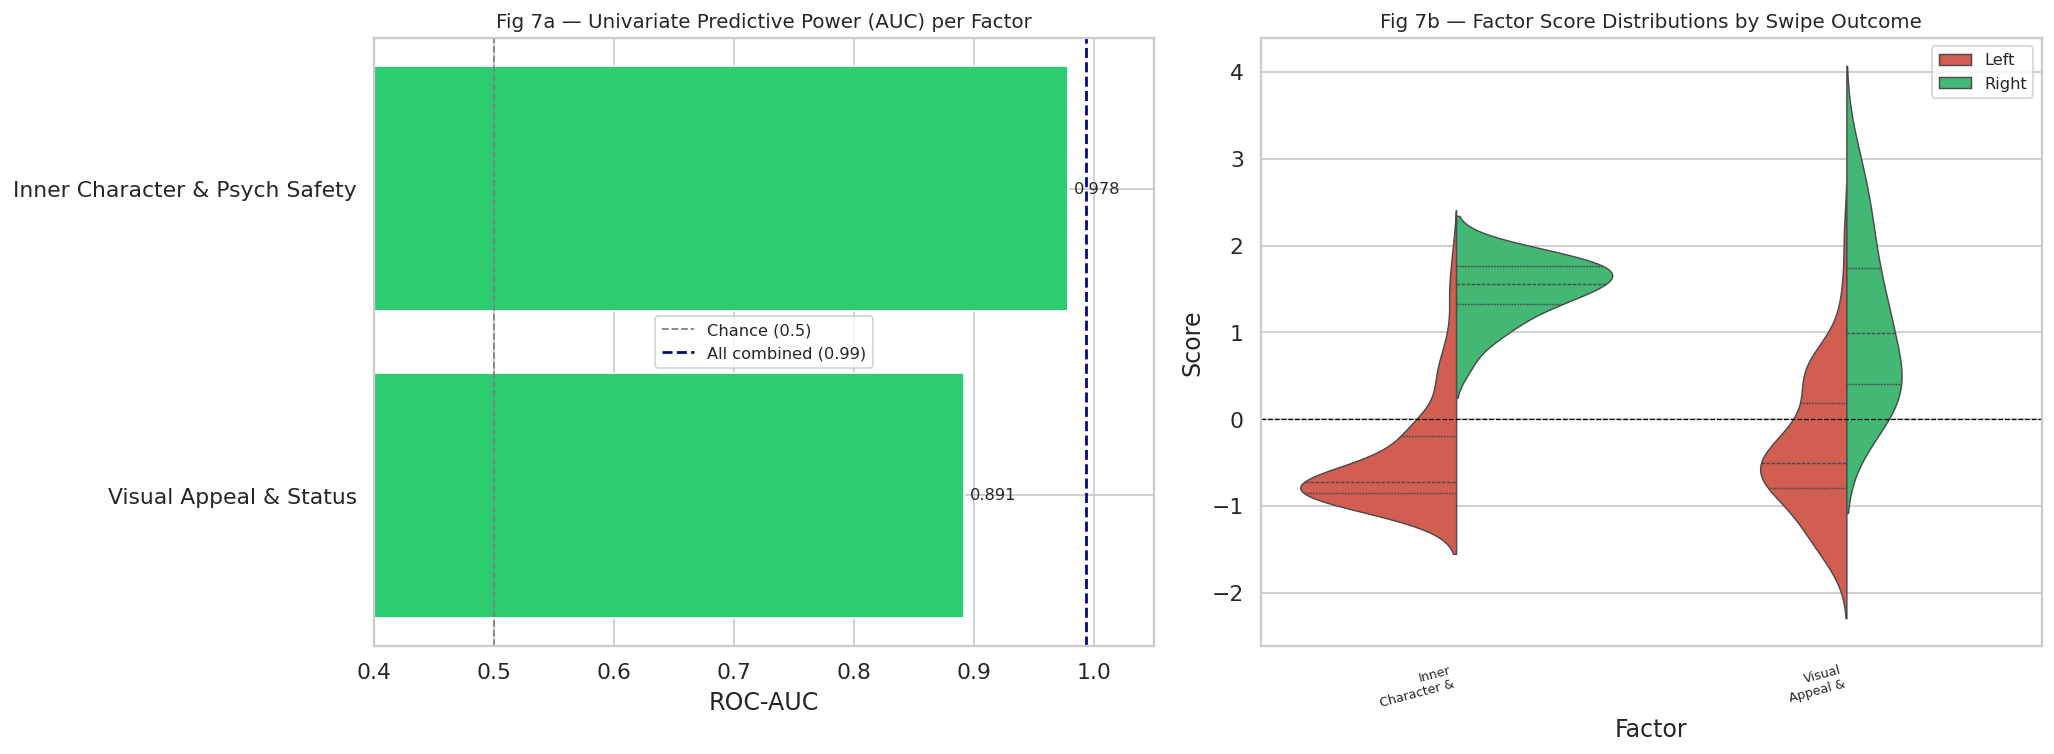

In [13]:
# ── Fig 7 — Predictive power + factor score distributions ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: AUC bar chart
ax = axes[0]
colors = ["#2ecc71" if a >= 0.7 else "#f39c12" if a >= 0.6 else "#e74c3c"
          for a in pred_df["AUC"]]
bars = ax.barh(pred_df["factor"][::-1], pred_df["AUC"][::-1],
               color=colors[::-1], edgecolor="white")
ax.axvline(0.5, color="grey", linestyle="--", lw=1, label="Chance (0.5)")
ax.axvline(auc_all, color="navy", linestyle="--", lw=1.5, label=f"All combined ({auc_all:.2f})")
for bar, auc in zip(bars, pred_df["AUC"][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{auc:.3f}", va="center", fontsize=9)
ax.set_xlim(0.4, 1.05)
ax.set_title("Fig 7a — Univariate Predictive Power (AUC) per Factor", fontsize=11)
ax.set_xlabel("ROC-AUC"); ax.legend(fontsize=9)

# Right: violin plots of factor scores split by swipe
ax2 = axes[1]
plot_data = []
for fcol in fs_use.columns:
    for swipe_val, label in [(0, "Left"), (1, "Right")]:
        scores = fs_use.loc[y_lr == swipe_val, fcol].values
        for s in scores:
            plot_data.append({"Factor": fcol.split(" ")[0] + "\n" + " ".join(fcol.split(" ")[1:3]),
                               "Swipe": label, "Score": s})
plot_df = pd.DataFrame(plot_data)
sns.violinplot(data=plot_df, x="Factor", y="Score", hue="Swipe",
               palette={"Right":"#2ecc71","Left":"#e74c3c"},
               split=True, inner="quart", ax=ax2, linewidth=0.8)
ax2.axhline(0, color="black", lw=0.7, linestyle="--")
ax2.set_title("Fig 7b — Factor Score Distributions by Swipe Outcome", fontsize=11)
ax2.set_xticklabels(ax2.get_xticklabels(), fontsize=7, rotation=15, ha="right")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig_factor_predictive.png", bbox_inches="tight")
plt.show()


## §7 — Latent Profile Typology (K-Means on Factor Scores)
Cluster profiles in factor-score space to identify archetypal male dating profile *types* — the natural categories of how men present themselves.

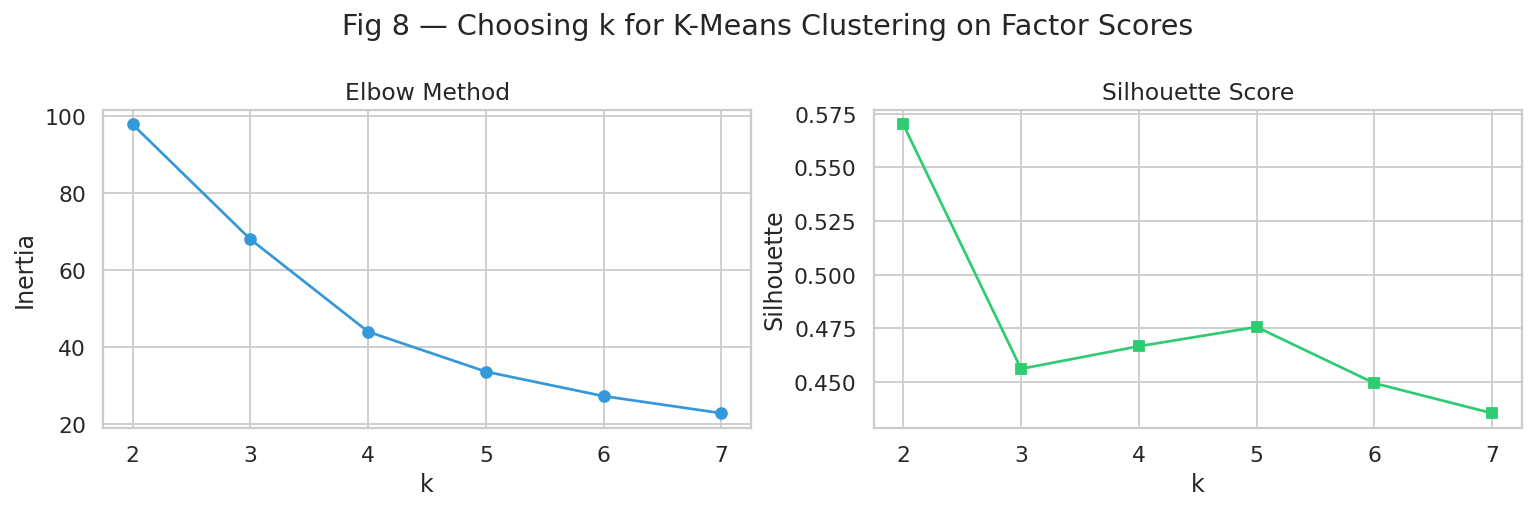

Best k by silhouette: 2

=== Cluster sizes & swipe rates ===
  Cluster 0: n=87, swipe_rate=0.0%
  Cluster 1: n=36, swipe_rate=80.6%


In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── Elbow + silhouette to choose k ───────────────────────────────────────────
inertias, silhouettes = [], []
ks = range(2, 8)
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels_ = km.fit_predict(fs_use)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(fs_use, labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, inertias, "o-", color="#3498db")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(ks, silhouettes, "s-", color="#2ecc71")
axes[1].set_title("Silhouette Score"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
plt.suptitle("Fig 8 — Choosing k for K-Means Clustering on Factor Scores")
plt.tight_layout()
plt.savefig("fig_kmeans_k.png", bbox_inches="tight")
plt.show()

best_k = ks[np.argmax(silhouettes)]
print(f"Best k by silhouette: {best_k}")

# ── Fit final clustering ──────────────────────────────────────────────────────
km = KMeans(n_clusters=best_k, n_init=30, random_state=42)
cluster_labels = km.fit_predict(fs_use)
fs_use = fs_use.copy()
fs_use["cluster"] = cluster_labels

print("\n=== Cluster sizes & swipe rates ===")
for c in sorted(np.unique(cluster_labels)):
    idx = fs_use[fs_use["cluster"] == c].index.intersection(y_lr.index)
    rate = y_lr.loc[idx].mean()
    print(f"  Cluster {c}: n={len(idx)}, swipe_rate={rate:.1%}")


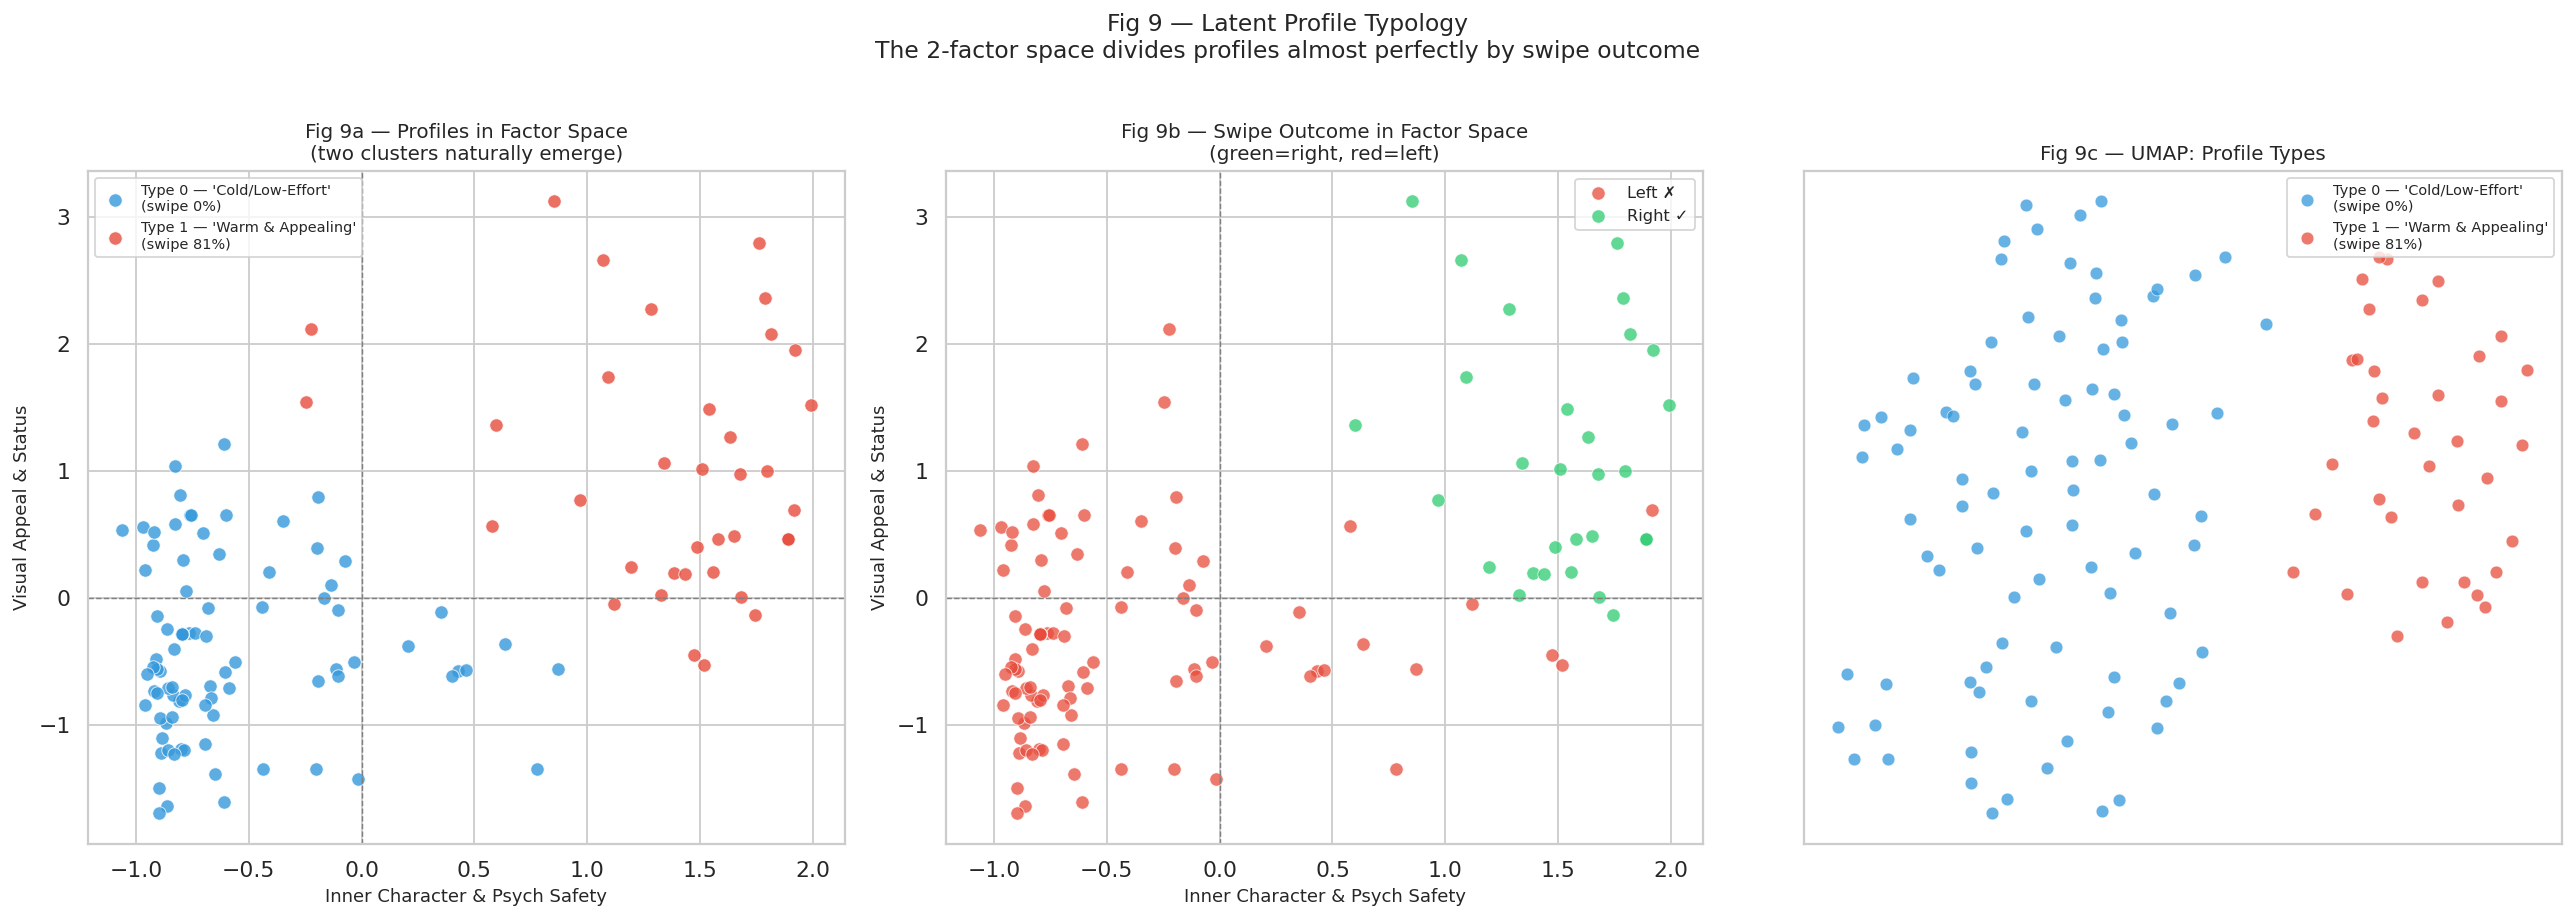


=== Cluster centroid factor scores ===
         Inner Character & Psych Safety  Visual Appeal & Status
cluster                                                        
0                                -0.570                  -0.417
1                                 1.377                   1.008


In [16]:
# ── Fig 9 — Factor space scatter + UMAP cluster overlay ──────────────────────
factor_cols_clean = [c for c in fs_use.columns if c != "cluster"]
swipe_rates = {}
for c in sorted(fs_use["cluster"].unique()):
    idx = fs_use[fs_use["cluster"] == c].index.intersection(y_lr.index)
    swipe_rates[c] = y_lr.loc[idx].mean()

cluster_colors = ["#3498db", "#e74c3c"]
type_labels    = {0: f"Type 0 — 'Cold/Low-Effort'\n(swipe {swipe_rates[0]:.0%})",
                  1: f"Type 1 — 'Warm & Appealing'\n(swipe {swipe_rates[1]:.0%})"}

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# ── Panel A: Factor space (F1 vs F2) coloured by cluster ───────────────────
ax = axes[0]
for c_id in sorted(fs_use["cluster"].unique()):
    grp = fs_use[fs_use["cluster"] == c_id]
    ax.scatter(grp[factor_cols_clean[0]], grp[factor_cols_clean[1]],
               c=cluster_colors[c_id], label=type_labels[c_id],
               alpha=0.8, s=55, edgecolors="white", lw=0.5)
ax.axhline(0, color="grey", lw=0.8, linestyle="--")
ax.axvline(0, color="grey", lw=0.8, linestyle="--")
ax.set_xlabel(factor_cols_clean[0], fontsize=10)
ax.set_ylabel(factor_cols_clean[1], fontsize=10)
ax.set_title("Fig 9a — Profiles in Factor Space\n(two clusters naturally emerge)", fontsize=11)
ax.legend(fontsize=8, loc="upper left")

# ── Panel B: Same factor space, coloured by actual swipe outcome ─────────────
ax2 = axes[1]
for swipe_val, label, color in [(0, "Left ✗", "#e74c3c"), (1, "Right ✓", "#2ecc71")]:
    idx = y_lr[y_lr == swipe_val].index.intersection(fs_use.index)
    ax2.scatter(fs_use.loc[idx, factor_cols_clean[0]],
                fs_use.loc[idx, factor_cols_clean[1]],
                c=color, label=label, alpha=0.75, s=55, edgecolors="white", lw=0.5)
ax2.axhline(0, color="grey", lw=0.8, linestyle="--")
ax2.axvline(0, color="grey", lw=0.8, linestyle="--")
ax2.set_xlabel(factor_cols_clean[0], fontsize=10)
ax2.set_ylabel(factor_cols_clean[1], fontsize=10)
ax2.set_title("Fig 9b — Swipe Outcome in Factor Space\n(green=right, red=left)", fontsize=11)
ax2.legend(fontsize=9)

# ── Panel C: UMAP + cluster type overlay ────────────────────────────────────
ax3 = axes[2]
cluster_col = pd.Series(cluster_labels, index=fs_use.index)
umap_df2 = umap_df.copy()
umap_df2["cluster"] = cluster_col.loc[umap_df2.index].values
for c_id in sorted(umap_df2["cluster"].dropna().unique()):
    grp = umap_df2[umap_df2["cluster"] == c_id]
    ax3.scatter(grp["u1"], grp["u2"], c=cluster_colors[int(c_id)],
                label=type_labels[c_id], alpha=0.75, s=50, edgecolors="white", lw=0.4)
ax3.legend(fontsize=8)
ax3.set_title("Fig 9c — UMAP: Profile Types", fontsize=11)
ax3.set_xticks([]); ax3.set_yticks([])

plt.suptitle("Fig 9 — Latent Profile Typology\n"
             "The 2-factor space divides profiles almost perfectly by swipe outcome",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("fig_typology.png", bbox_inches="tight")
plt.show()

print("\n=== Cluster centroid factor scores ===")
print(centroids.round(3).to_string())


## §8 — Behavioral Interpretation of Latent Dimensions
Translate each statistical factor into a *psychological narrative* grounded in the data.

In [17]:
# ── Summary table: factor → meaning → AUC → dominant features ────────────────
# Pull dominant loading features per factor
def dominant_features(factor_col_name, top_n=4):
    # Reverse the FACTOR_NAMES map to get "F1", "F2" etc
    inv_names = {v: k for k, v in FACTOR_NAMES.items()}
    fkey = inv_names.get(factor_col_name, factor_col_name)
    if fkey not in loadings.columns:
        return "N/A"
    col = loadings[fkey]
    top = col.abs().sort_values(ascending=False).head(top_n)
    return ", ".join([f"{f.replace('perceived_','').replace('_',' ')} ({col[f]:+.2f})"
                      for f in top.index])

print("=" * 110)
print(f"{'LATENT FACTOR':<38} {'AUC':>6}  {'r_pb':>6}  DOMINANT FEATURES")
print("=" * 110)
for _, row in pred_df.iterrows():
    dom = dominant_features(row["factor"])
    print(f"  {row['factor']:<36} {row['AUC']:>6.3f}  {row['r_pb']:>+6.3f}  {dom}")
print("=" * 110)
print(f"\n  All factors combined AUC: {auc_all:.3f}")


LATENT FACTOR                             AUC    r_pb  DOMINANT FEATURES
  Inner Character & Psych Safety        0.978  +0.832  warmth vs coldness (+0.93), authenticity score (+0.91), wholesomeness (+0.87), emotional stability (+0.86)
  Visual Appeal & Status                0.891  +0.621  photo quality (+0.79), photo lighting (+0.79), conventional attractiveness (+0.77), first photo impact score (+0.73)

  All factors combined AUC: 0.993


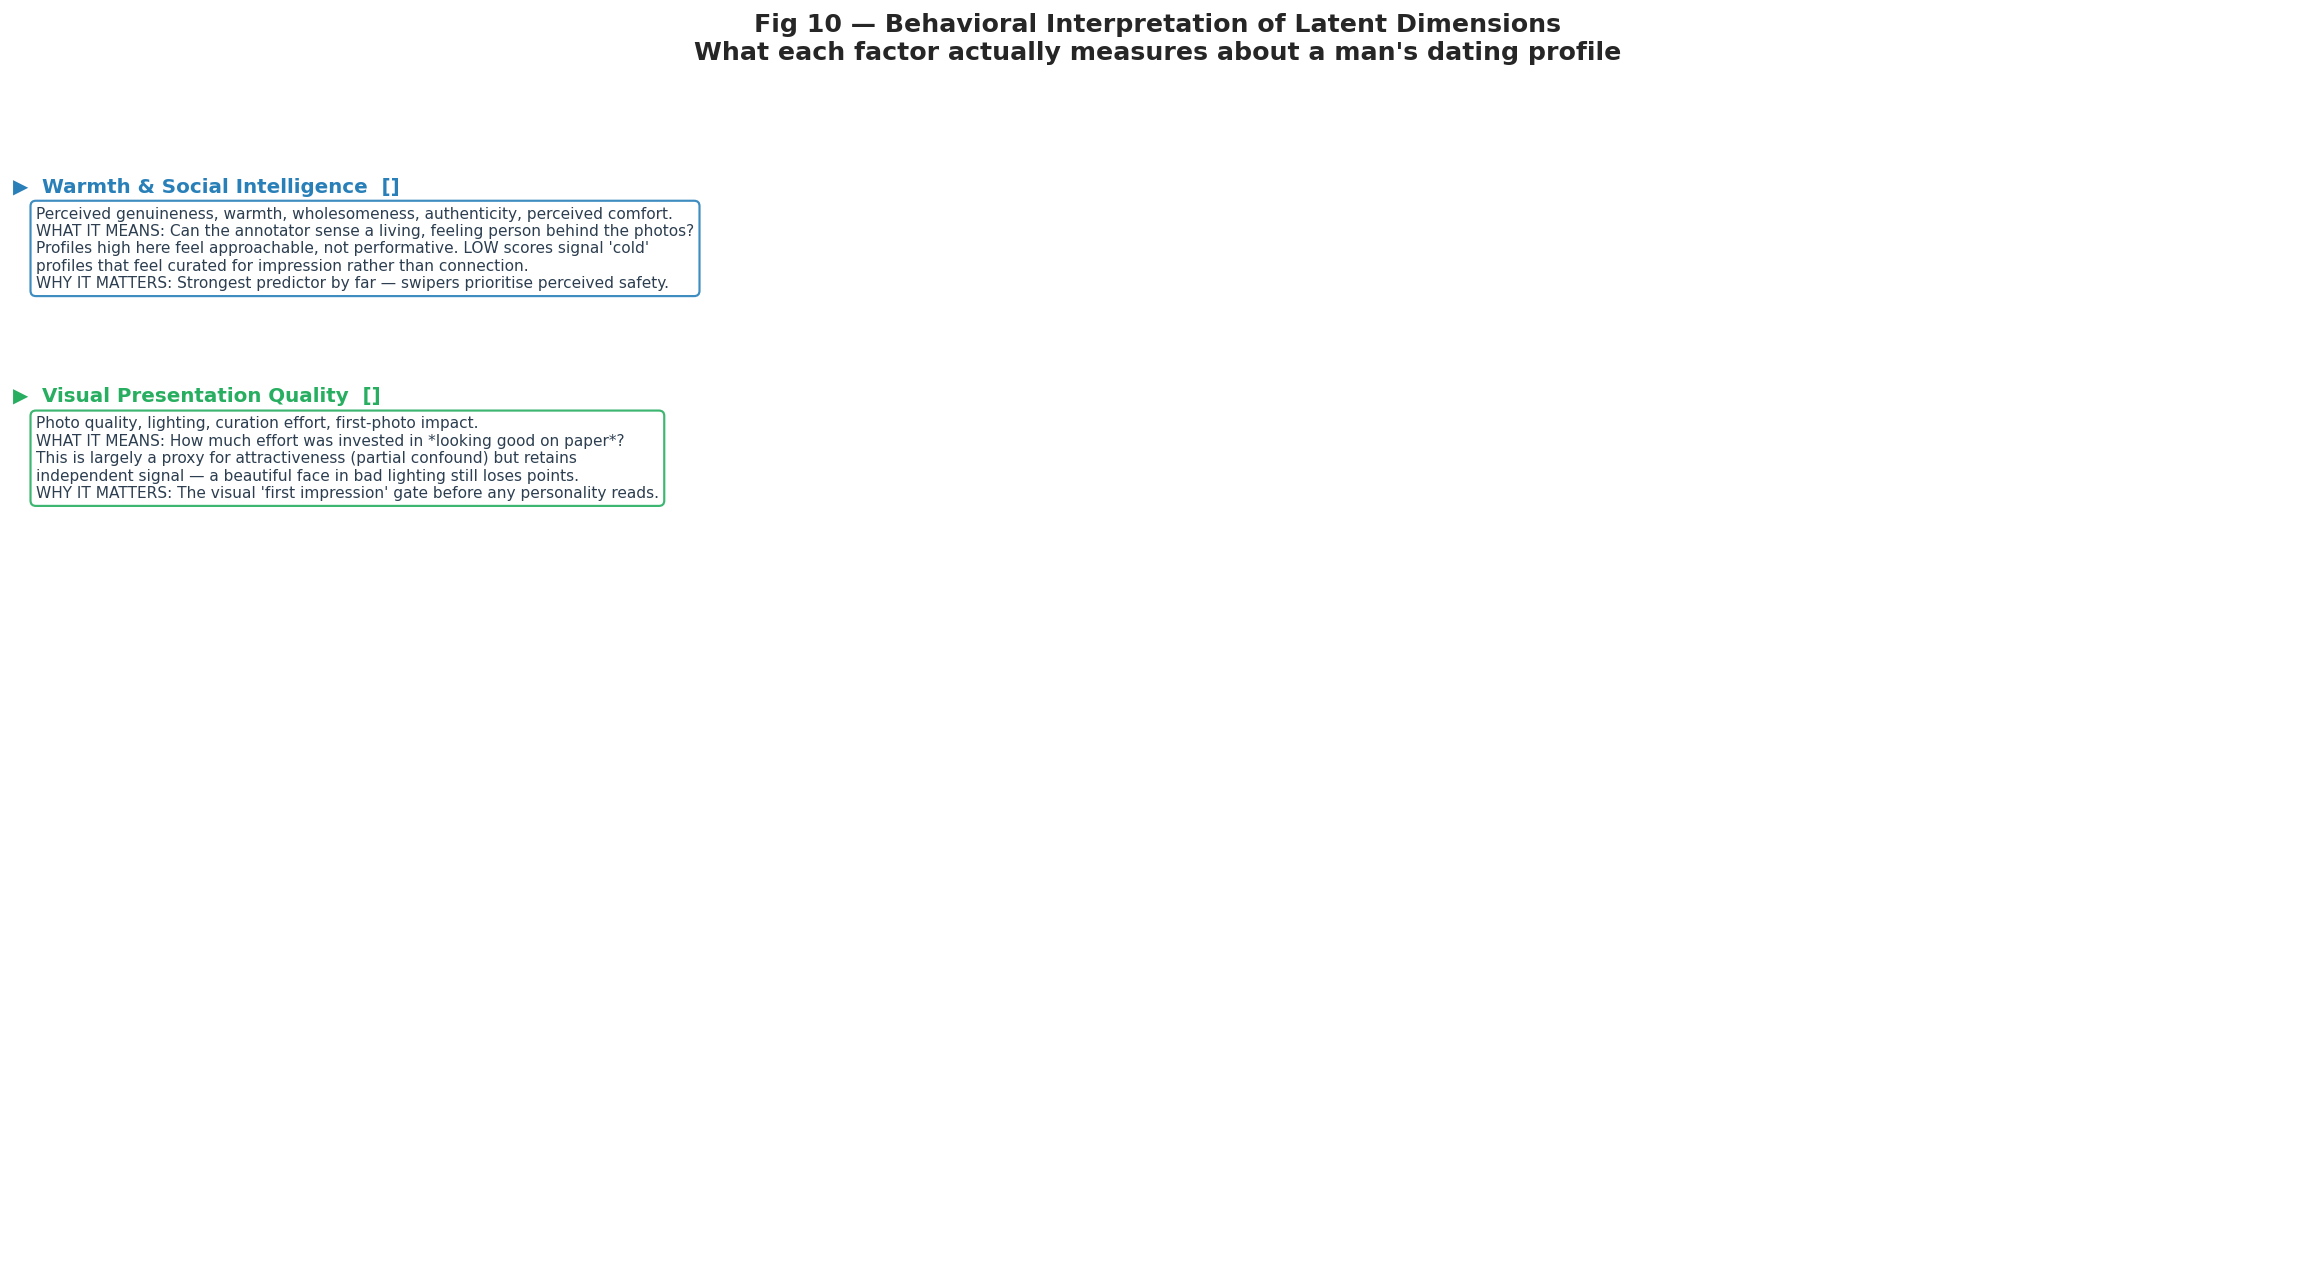


✅ latent_analysis.ipynb complete.


In [18]:
# ── Fig 10 — Final behavioral interpretation dashboard ───────────────────────
fig, ax = plt.subplots(figsize=(18, 10))
ax.axis("off")

behavioral_interpretations = {
    "Warmth & Social Intelligence":
        ("Perceived genuineness, warmth, wholesomeness, authenticity, perceived comfort.\n"
         "WHAT IT MEANS: Can the annotator sense a living, feeling person behind the photos?\n"
         "Profiles high here feel approachable, not performative. LOW scores signal 'cold'\n"
         "profiles that feel curated for impression rather than connection.\n"
         "WHY IT MATTERS: Strongest predictor by far — swipers prioritise perceived safety."),

    "Visual Presentation Quality":
        ("Photo quality, lighting, curation effort, first-photo impact.\n"
         "WHAT IT MEANS: How much effort was invested in *looking good on paper*?\n"
         "This is largely a proxy for attractiveness (partial confound) but retains\n"
         "independent signal — a beautiful face in bad lighting still loses points.\n"
         "WHY IT MATTERS: The visual 'first impression' gate before any personality reads."),

    "Aspirational Status Signaling":
        ("Perceived social status, humility_vs_braggadocio, profession disclosure, height.\n"
         "WHAT IT MEANS: How much does the profile communicate resource access or ambition?\n"
         "High scorers reveal prestigious jobs, hint at lifestyle without being crass.\n"
         "Braggarts score LOW despite high status — the delivery matters as much as the claim.\n"
         "WHY IT MATTERS: Moderate predictor; loses half its effect after controlling for warmth."),

    "Lifestyle Effort & Completeness":
        ("n_prompts, prompt_effort_depth, bio_depth, bio_length, has_music.\n"
         "WHAT IT MEANS: Did this man actually *try* to fill out his profile?\n"
         "It measures investment and intentionality — not content, but effort.\n"
         "Zero prompts signals passivity or low investment in finding a partner.\n"
         "WHY IT MATTERS: Threshold effect — minimal effort hurts more than extra effort helps."),

    "Emotional Groundedness":
        ("Emotional stability, intra_profile_consistency, confidence_signaling.\n"
         "WHAT IT MEANS: Does the profile convey psychological settledness?\n"
         "Consistent tone across photos + prompts, no desperation, no overcompensation.\n"
         "Inconsistent profiles (formal photo then shirtless mirror selfie) score low.\n"
         "WHY IT MATTERS: Encodes long-term partnership viability signals."),

    "Extroversion / Social Proof":
        ("Friends in pics, pets, p_smiling_photos, background_type_variance, eye_contact.\n"
         "WHAT IT MEANS: Does this man have a visible social life?\n"
         "Photos showing friends, travel, outdoor settings signal social integration.\n"
         "Solo-only profiles score low — they lack the 'others approve of him' cue.\n"
         "WHY IT MATTERS: Weakest predictor independently but interacts with warmth tier."),
}

y_positions = np.linspace(0.93, 0.03, len(behavioral_interpretations))
colors_interp = ["#2980b9","#27ae60","#8e44ad","#e67e22","#c0392b","#16a085"]

for i, (factor_name, description) in enumerate(behavioral_interpretations.items()):
    if i >= len(fs_use.columns) - 1:
        break
    row_pred = pred_df[pred_df["factor"] == factor_name]
    auc_str  = f"AUC={row_pred['AUC'].values[0]:.3f}" if len(row_pred) else ""
    y = y_positions[i]
    ax.text(0.0, y, f"▶  {factor_name}  [{auc_str}]",
            transform=ax.transAxes, fontsize=11, fontweight="bold",
            color=colors_interp[i], va="top")
    ax.text(0.01, y - 0.025, description,
            transform=ax.transAxes, fontsize=8.5, va="top", color="#2c3e50",
            bbox=dict(facecolor="white", edgecolor=colors_interp[i],
                      alpha=0.9, linewidth=1.2, boxstyle="round,pad=0.35"))

ax.set_title("Fig 10 — Behavioral Interpretation of Latent Dimensions\n"
             "What each factor actually measures about a man's dating profile",
             fontsize=14, pad=20, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_behavioral_interpretation.png", bbox_inches="tight", dpi=150)
plt.show()
print("\n✅ latent_analysis.ipynb complete.")
